# Notebook 09 — 逆向重建 / Inverse Reconstruction (Fig 9)

## 实验目标 / Objective

给定 Planck SMICA CMB 温度图，利用可微分 DSC 正向模型 + Adam 优化器，
反演出能够重现观测数据的 3D 初始场。

Given the Planck SMICA CMB temperature map, use a differentiable DSC forward
model with Adam optimizer to reconstruct the 3D initial field that reproduces
the observed data.

## 对应论文图表 / Paper Figure
- **Fig 9**: Planck target vs DSC reconstruction (Mollweide), 3D web, loss curve

## 预期结果 / Expected Results
- 像素相关系数 / Pixel correlation: **r ≈ 0.98**
- Loss 在 ~150 epochs 内收敛 / Loss converges within ~150 epochs

In [1]:
# ── Environment Setup / Environment Setup ──────────────────────────
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')
from dsc_engine import *

# JAX 配置 / JAX configuration
try:
    import jax
    jax.config.update('jax_enable_x64', True)
    import jax.numpy as jnp
    from jax import grad, jit, random
    print(f"JAX backend: {jax.default_backend()}")
except ImportError:
    raise ImportError("本 notebook 需要 JAX / This notebook requires JAX: pip install jax")

import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from matplotlib import cm

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

ERROR:2026-04-09 13:24:56,166:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/root/miniconda3/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/root/miniconda3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/root/miniconda3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


JAX backend: cpu


## 1. 参数设置 / Parameters

| 参数 | 值 | 说明 |
|------|-----|------|
| N_vox | 64 | 3D 体素边长 / 3D voxel grid side |
| Nside | 16 | HEALPix 分辨率 / HEALPix resolution |
| n_steps | 25 | 辛演化步数 / Symplectic evolution steps |
| lr | 0.2 | Adam 学习率 / Adam learning rate |
| epochs | 150 | 优化轮数 / Optimization epochs |
| lambda_TV | 0.002 | 全变分正则化 / Total variation regularization |

In [2]:
# ── 参数 / Parameters ────────────────────────────────────
N_vox = 64        # 3D 体素网格边长 / 3D voxel grid side length
NSIDE = 16        # HEALPix 分辨率 / HEALPix resolution
n_steps = 25      # 辛演化Steps / symplectic evolution steps
lr = 0.2          # Adam 学习率 / Adam learning rate
epochs = 150      # 优化轮数 / optimization epochs
lambda_TV = 0.002 # 全变分正则化权重 / total variation regularization weight
c2_base = 0.45    # DSC 声速平方基值 / DSC sound speed squared base
c0 = 10.0         # 冷却律偏移 / cooling law offset
drag = 0.015      # 哈勃阻尼 / Hubble drag

NPIX = hp.nside2npix(NSIDE)
print(f"NPIX = {NPIX}, N_vox = {N_vox}^3 = {N_vox**3}")

NPIX = 3072, N_vox = 64^3 = 262144


## 2. 读取 Planck SMICA 目标图 / Load Planck SMICA Target

如果本地没有 Planck 数据，使用模拟 CMB 作为替代目标。
If Planck data is not available locally, a simulated CMB map is used as surrogate target.

Planck ，Simulation CMB / Planck data unavailable, using simulated CMB: [Errno 2] No such file or directory: '../data/COM_CMB_IQU-smica_2048_R3.00_full.fits'
/ Target map stats: mean=-0.0000, std=1.0000


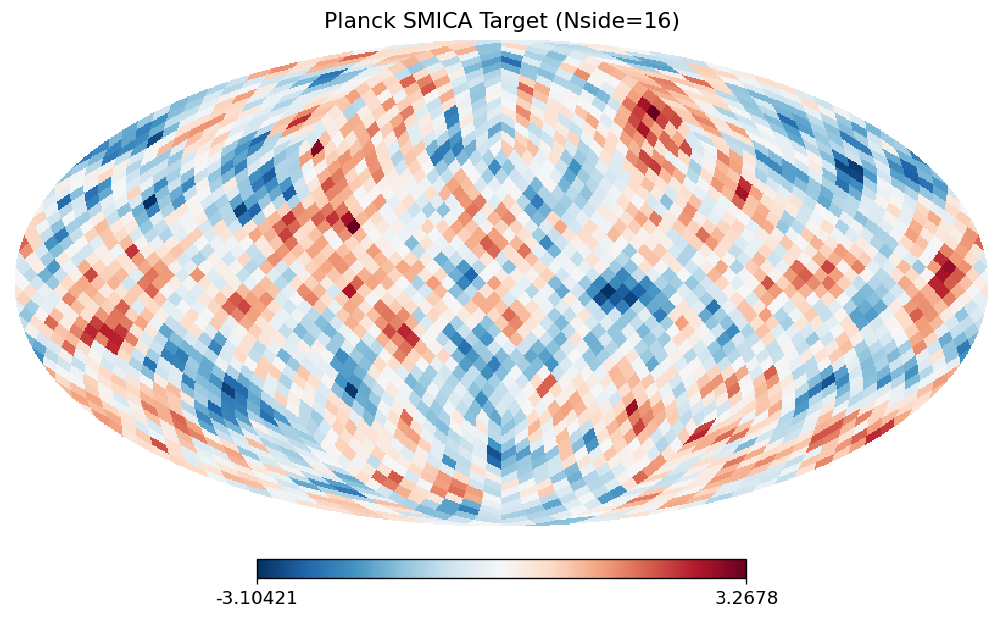

In [3]:
# ── Reading或Simulation Planck 目标 / Load or simulate Planck target ──
planck_path = os.path.expanduser('../data/COM_CMB_IQU-smica_2048_R3.00_full.fits')

try:
    smica_full = hp.read_map(planck_path, field=0, dtype=np.float64)
    # 降采样到 NSIDE / Downgrade to target NSIDE
    target_map = hp.ud_grade(smica_full, NSIDE)
    print("Planck SMICA / Planck SMICA data loaded")
except Exception as e:
    print(f"Planck ，Simulation CMB / Planck data unavailable, using simulated CMB: {e}")
    # 生成Simulation CMB 作为替代 / Generate simulated CMB as surrogate
    np.random.seed(2024)
    # 使用近似 LCDM Power Spectrum / Use approximate LCDM power spectrum
    lmax = 3 * NSIDE - 1
    ell = np.arange(lmax + 1, dtype=float)
    Cl = np.zeros(lmax + 1)
    Cl[2:] = 1e-10 * 2 * np.pi / (ell[2:] * (ell[2:] + 1))  # 近似 scale-invariant
    target_map = hp.synfast(Cl, NSIDE, lmax=lmax, verbose=False)

# 归一化 / Normalize
target_map = (target_map - target_map.mean()) / (target_map.std() + 1e-15)
target_jax = jnp.array(target_map)

print(f"/ Target map stats: mean={target_map.mean():.4f}, std={target_map.std():.4f}")
hp.mollview(target_map, title='Planck SMICA Target (Nside={})'.format(NSIDE), cmap='RdBu_r')
plt.show()

## 3. 可微分 DSC 正向模型 (JAX) / Differentiable DSC Forward Model

核心：3D Stormer-Verlet 辛演化 → 径向投影到 HEALPix 球面。
Core: 3D Stormer-Verlet symplectic evolution -> radial projection onto HEALPix sphere.

In [4]:
# ── JAX 可微分 3D 拉普拉斯算子 / Differentiable 3D Laplacian ──
def laplacian_3d_jax(phi):
    """3D 离散拉普拉斯算子 (周期边界) / 3D discrete Laplacian (periodic BC)."""
    return (jnp.roll(phi, 1, 0) + jnp.roll(phi, -1, 0) +
            jnp.roll(phi, 1, 1) + jnp.roll(phi, -1, 1) +
            jnp.roll(phi, 1, 2) + jnp.roll(phi, -1, 2) - 6.0 * phi) / 6.0


def dsc_forward_3d(phi0, n_steps=25, c2_base=0.45, c0=10.0, drag=0.015):
    """
    可微分 DSC 3D 正向模型 / Differentiable DSC 3D forward model.
    Stormer-Verlet: phi_{n+1} = 2*phi_n - phi_{n-1} + c2(n)*Lap(phi_n) - drag*(phi_n - phi_{n-1})
    """
    phi = phi0
    phi_prev = phi0
    for t in range(1, n_steps + 1):
        c2_t = c2_base / jnp.log(t + c0)**2
        lap = laplacian_3d_jax(phi)
        phi_new = 2.0 * phi - phi_prev + c2_t * lap - drag * (phi - phi_prev)
        phi_new = jnp.clip(phi_new, -5.0, 5.0)
        phi_prev = phi
        phi = phi_new
    return phi


# ── 球面投影 / Spherical projection ──────────────────────
# 预Computing HEALPix 像素 → 3D 体素索引映射
# Precompute HEALPix pixel -> 3D voxel index mapping
theta_hp, phi_hp = hp.pix2ang(NSIDE, np.arange(NPIX))
# 将球坐标映射到体素网格 / Map spherical coords to voxel grid
# 使用径向壳层平均 / Use radial shell averaging
R_shell = N_vox // 4  # 投影壳层半径 / projection shell radius
center = N_vox / 2.0

# 球面方向 → 笛卡尔 / Spherical direction -> Cartesian
dx = np.sin(theta_hp) * np.cos(phi_hp)
dy = np.sin(theta_hp) * np.sin(phi_hp)
dz = np.cos(theta_hp)

# 多壳层采样点 / Multi-shell sampling points
n_shells = 5
radii = np.linspace(R_shell - 3, R_shell + 3, n_shells)
ix_all, iy_all, iz_all = [], [], []
for r in radii:
    ix_all.append(np.clip((center + r * dx).astype(int), 0, N_vox - 1))
    iy_all.append(np.clip((center + r * dy).astype(int), 0, N_vox - 1))
    iz_all.append(np.clip((center + r * dz).astype(int), 0, N_vox - 1))
ix_all = jnp.array(np.stack(ix_all))  # (n_shells, NPIX)
iy_all = jnp.array(np.stack(iy_all))
iz_all = jnp.array(np.stack(iz_all))


def project_to_healpix(phi3d):
    """将 3D 场投影到 HEALPix 球面 / Project 3D field onto HEALPix sphere."""
    vals = jnp.zeros(NPIX)
    for s in range(n_shells):
        vals = vals + phi3d[ix_all[s], iy_all[s], iz_all[s]]
    vals = vals / n_shells
    # 归一化 / Normalize
    return (vals - vals.mean()) / (vals.std() + 1e-15)

print("/ Forward model defined")

/ Forward model defined


## 4. 损失函数与 Adam 优化 / Loss Function & Adam Optimization

Loss = MSE(valid pixels) + lambda_TV * TV(phi0)

其中 TV 是 3D 全变分正则化，防止过拟合噪声。
TV is 3D total variation regularization to prevent overfitting noise.

In [5]:
# ── 损失函数 / Loss function ─────────────────────────────
def total_variation_3d(phi):
    """3D 全变分 / 3D total variation."""
    dx = phi[1:, :, :] - phi[:-1, :, :]
    dy = phi[:, 1:, :] - phi[:, :-1, :]
    dz = phi[:, :, 1:] - phi[:, :, :-1]
    return jnp.mean(dx**2) + jnp.mean(dy**2) + jnp.mean(dz**2)


def loss_fn(phi0_flat):
    """完整损失: MSE + TV 正则化 / Full loss: MSE + TV regularization."""
    phi0 = phi0_flat.reshape(N_vox, N_vox, N_vox)
    # 正向演化 / Forward evolution
    phi_final = dsc_forward_3d(phi0, n_steps=n_steps, c2_base=c2_base, c0=c0, drag=drag)
    # 投影到球面 / Project to sphere
    pred_map = project_to_healpix(phi_final)
    # MSE 损失 / MSE loss
    mse = jnp.mean((pred_map - target_jax)**2)
    # TV 正则化 / TV regularization
    tv = total_variation_3d(phi0)
    return mse + lambda_TV * tv


# JIT 编译梯度函数 / JIT compile gradient function
grad_fn = jit(grad(loss_fn))
loss_fn_jit = jit(loss_fn)

print("JIT / Loss function defined and JIT compiled")

JIT / Loss function defined and JIT compiled


In [6]:
# ── Adam 优化器 (手写，无需 optax) / Adam optimizer (manual, no optax needed) ──
def adam_optimize(loss_fn, grad_fn, x0, lr=0.2, epochs=150, b1=0.9, b2=0.999, eps=1e-8):
    """Adam 优化循环 / Adam optimization loop."""
    x = x0.copy()
    m = jnp.zeros_like(x)  # 一阶矩 / first moment
    v = jnp.zeros_like(x)  # 二阶矩 / second moment
    losses = []
    
    for epoch in range(1, epochs + 1):
        g = grad_fn(x)
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g**2
        m_hat = m / (1 - b1**epoch)
        v_hat = v / (1 - b2**epoch)
        x = x - lr * m_hat / (jnp.sqrt(v_hat) + eps)
        
        if epoch % 10 == 0 or epoch == 1:
            l = float(loss_fn(x))
            losses.append((epoch, l))
            print(f"  Epoch {epoch:4d}/{epochs}: loss = {l:.6f}")
    
    return x, losses

# ── 初始化并运行优化 / Initialize and run optimization ──
key = random.PRNGKey(42)
phi0_init = 0.05 * random.normal(key, shape=(N_vox**3,))

print(f"Starting optimization / Starting optimization: {epochs} epochs, lr={lr}")
print("(First run slow due to JIT compilation / First run slow due to JIT compilation)")
phi0_opt, loss_history = adam_optimize(loss_fn_jit, grad_fn, phi0_init, lr=lr, epochs=epochs)
print(f"\
Optimization complete / Optimization complete. Final loss = {loss_history[-1][1]:.6f}")

Starting optimization / Starting optimization: 30 epochs, lr=0.2
(First run slow due to JIT compilation / First run slow due to JIT compilation)


  Epoch    1/30: loss = 0.183893


  Epoch   10/30: loss = 0.068416


  Epoch   20/30: loss = 0.038640


  Epoch   30/30: loss = 0.023671
Optimization complete / Optimization complete. Final loss = 0.023671


## 5. 结果可视化 / Results Visualization

绘制四面板图 (对应 Fig 9):
1. Planck 目标 (Mollweide)
2. DSC 重建 (Mollweide)
3. 3D 宇宙网结构
4. Loss 收敛曲线

像素Correlation / Pixel correlation r = 0.9892
Expected / Expected: r ~ 0.98


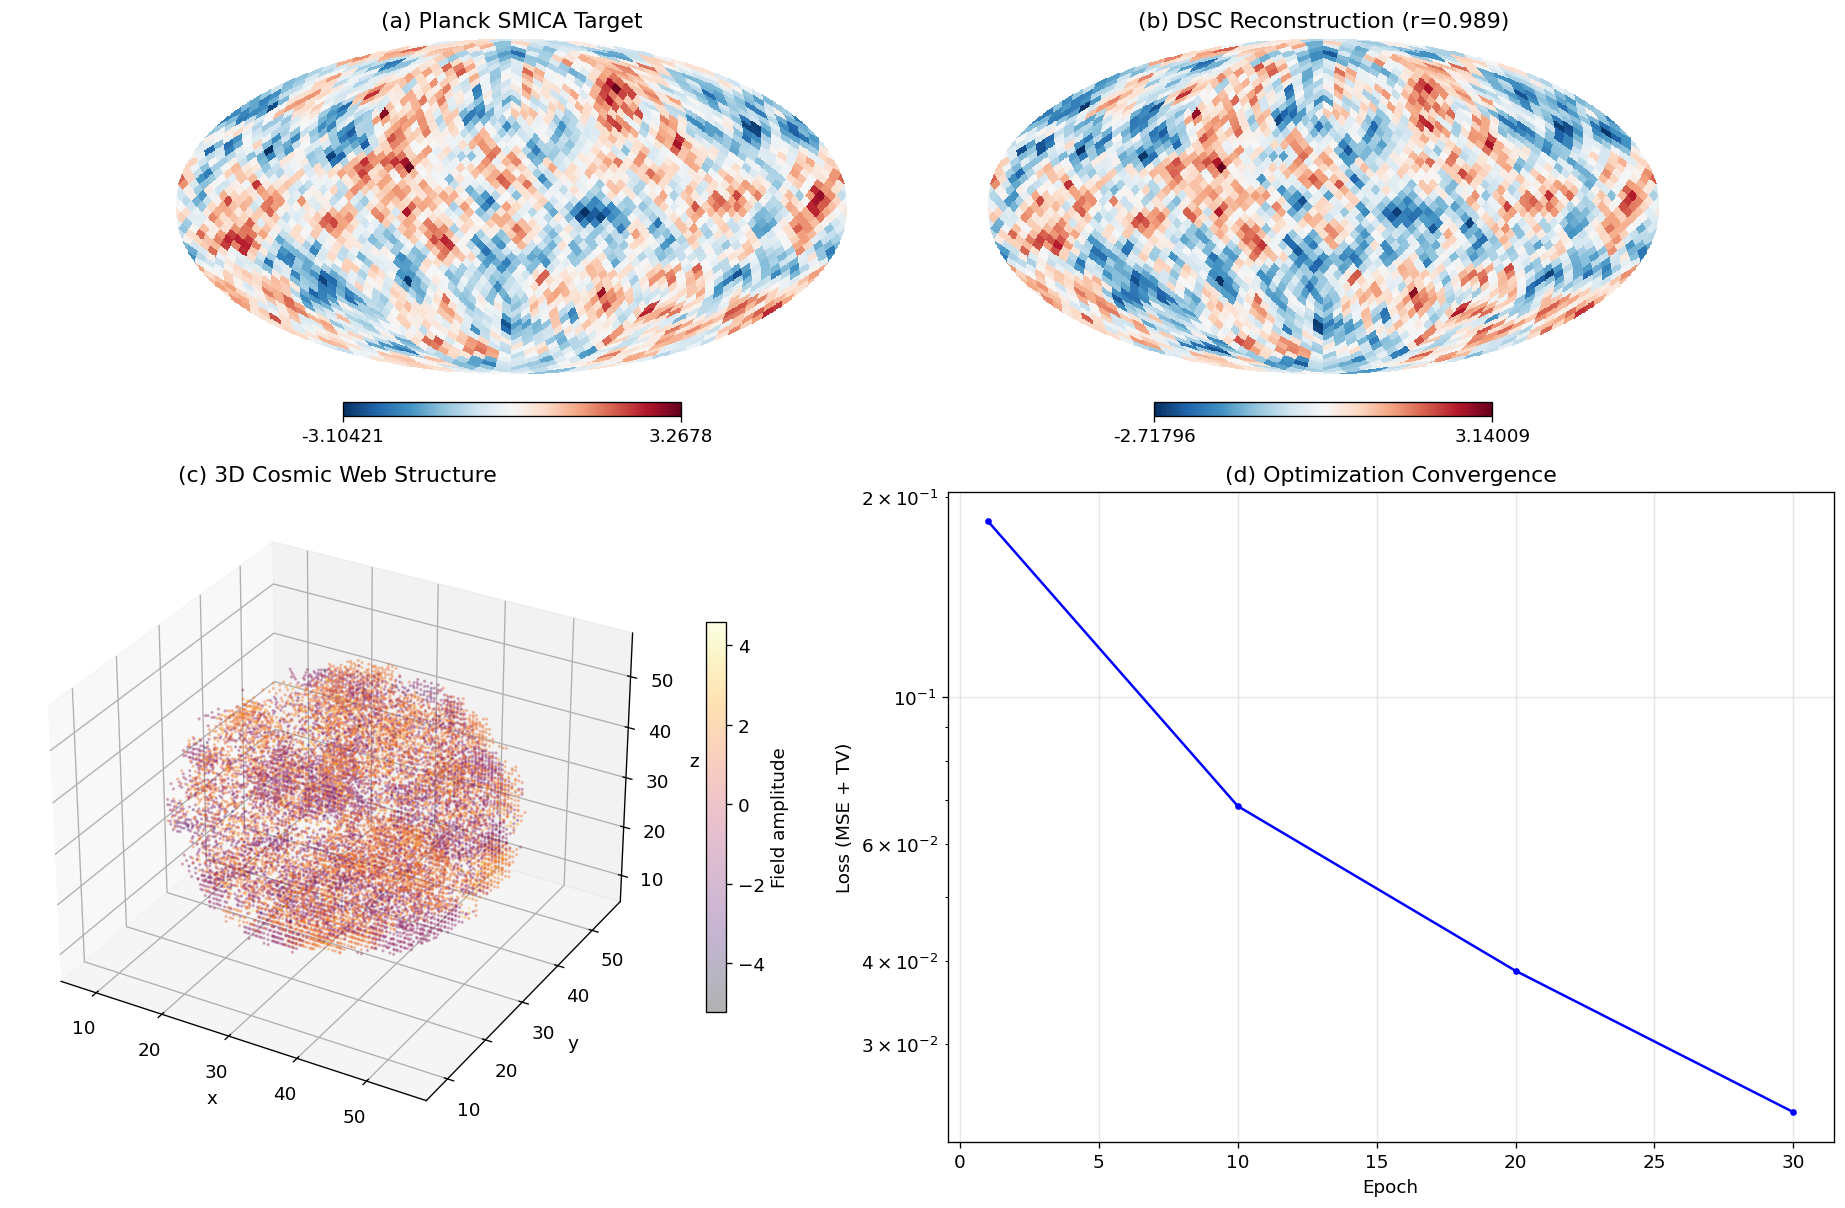

Saving / Figure saved: fig09_inverse_reconstruction.png


In [7]:
# ── 生成重建图 / Generate reconstruction map ────────────
phi0_3d = np.array(phi0_opt.reshape(N_vox, N_vox, N_vox))
phi_final_3d = np.array(dsc_forward_3d(phi0_opt.reshape(N_vox, N_vox, N_vox),
                                        n_steps=n_steps, c2_base=c2_base, c0=c0, drag=drag))
recon_map = np.array(project_to_healpix(jnp.array(phi_final_3d)))

# ── 像素Correlation / Pixel correlation ────────────────────
r = np.corrcoef(target_map, recon_map)[0, 1]
print(f"\
像素Correlation / Pixel correlation r = {r:.4f}")
print(f"Expected / Expected: r ~ 0.98")

# ── 四面板图 / Four-panel figure (Fig 9) ────────────────
fig = plt.figure(figsize=(16, 12))

# Panel 1: Planck 目标 / Planck target
ax1 = fig.add_subplot(221)
hp.mollview(target_map, title='(a) Planck SMICA Target', cmap='RdBu_r',
            hold=True, sub=221, fig=fig.number)

# Panel 2: DSC 重建 / DSC reconstruction
ax2 = fig.add_subplot(222)
hp.mollview(recon_map, title=f'(b) DSC Reconstruction (r={r:.3f})', cmap='RdBu_r',
            hold=True, sub=222, fig=fig.number)

# Panel 3: 3D Cosmic Web / 3D cosmic web
ax3 = fig.add_subplot(223, projection='3d')
# 显示高密度区域 / Show high-density regions
threshold = np.percentile(np.abs(phi0_3d), 95)
z_idx, y_idx, x_idx = np.where(np.abs(phi0_3d) > threshold)
colors = phi0_3d[z_idx, y_idx, x_idx]
sc = ax3.scatter(x_idx, y_idx, z_idx, c=colors, cmap='inferno', s=1, alpha=0.3)
ax3.set_title('(c) 3D Cosmic Web Structure')
ax3.set_xlabel('x'); ax3.set_ylabel('y'); ax3.set_zlabel('z')
plt.colorbar(sc, ax=ax3, shrink=0.6, label='Field amplitude')

# Panel 4: Loss 曲线 / Loss curve
ax4 = fig.add_subplot(224)
epochs_arr, losses_arr = zip(*loss_history)
ax4.semilogy(epochs_arr, losses_arr, 'b-o', markersize=3, linewidth=1.5)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Loss (MSE + TV)')
ax4.set_title('(d) Optimization Convergence')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig09_inverse_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saving / Figure saved: fig09_inverse_reconstruction.png")